In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time




In [12]:
IMAGE_PATH = "test.png"


In [14]:

start = time.perf_counter()
gaussian = cv2.GaussianBlur(image, (5, 5), 0)
gaussian_time = time.perf_counter() - start

start = time.perf_counter()
median = cv2.medianBlur(image, 5)
median_time = time.perf_counter() - start

start = time.perf_counter()
average = cv2.blur(image, (5, 5))
average_time = time.perf_counter() - start

start = time.perf_counter()
laplacian = cv2.Laplacian(image, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)
laplacian_time = time.perf_counter() - start


In [15]:

start = time.perf_counter()
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)
sobel_magnitude = cv2.magnitude(
    sobel_x.astype(np.float32),
    sobel_y.astype(np.float32)
)
sobel_magnitude = cv2.convertScaleAbs(sobel_magnitude)
sobel_time = time.perf_counter() - start


In [16]:

images = [
    ("Original Image", image),
    ("Gaussian Blur", gaussian),
    ("Median Filter", median),
    ("Average Filter", average),
    ("Laplacian", laplacian),
    ("Sobel X", sobel_x),
    ("Sobel Y", sobel_y),
    ("Sobel Magnitude", sobel_magnitude),
]


In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

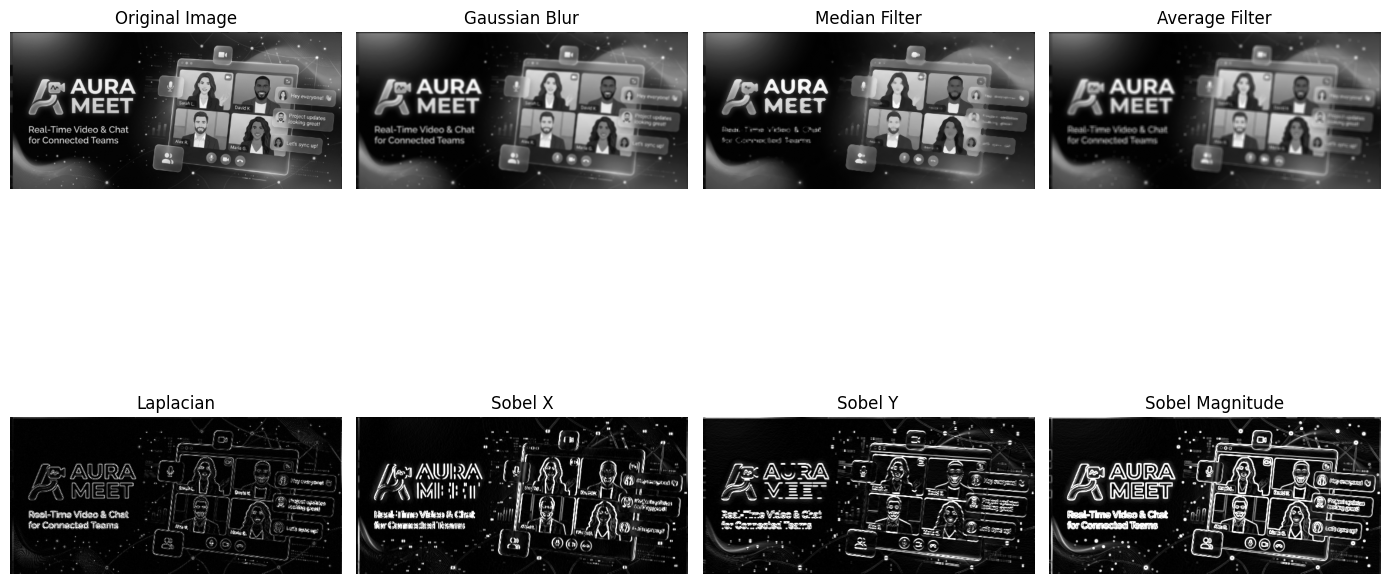

Filter execution times:
Gaussian Filter : 0.001172 seconds
Median Filter   : 0.002240 seconds
Average Filter  : 0.000871 seconds
Laplacian       : 0.003009 seconds
Sobel           : 0.007375 seconds


In [17]:

plt.figure(figsize=(14, 10))

for index, (title, result) in enumerate(images, start=1):
    plt.subplot(2, 4, index)
    plt.imshow(result, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Filter execution times:")
print(f"Gaussian Filter : {gaussian_time:.6f} seconds")
print(f"Median Filter   : {median_time:.6f} seconds")
print(f"Average Filter  : {average_time:.6f} seconds")
print(f"Laplacian       : {laplacian_time:.6f} seconds")
print(f"Sobel           : {sobel_time:.6f} seconds")

# Experiment 3: Spatial Filtering Techniques — Questions & Answers

---

### Q1. What is spatial filtering? How is it used in digital image processing?

**Spatial filtering** is a core digital image processing technique that operates directly on the pixel values of an image within a spatial neighborhood. It involves moving a small 2D array of coefficients—called a **kernel**, **mask**, or **template**—over an image to compute a new intensity value for each pixel based on its surrounding neighbors.

Mathematically, 2D spatial convolution is expressed as:
$$g(x, y) = \sum_{m=-a}^{a} \sum_{n=-b}^{b} w(m, n) \cdot f(x+m, y+n)$$
where $f(x, y)$ is the original image, $w(m, n)$ is the filter kernel of size $(2a+1) \times (2b+1)$, and $g(x, y)$ is the filtered output image.

**Applications in Digital Image Processing:**
1. **Noise Reduction:** Removing unwanted sensor noise (Gaussian, impulse/salt-and-pepper noise).
2. **Image Smoothing:** Blurring images to suppress fine, irrelevant details before feature extraction.
3. **Sharpening & Edge Enhancement:** Highlighting boundaries, fine lines, and abrupt intensity changes.
4. **Feature Extraction:** Identifying key structural elements such as corners, lines, and gradients for computer vision tasks.

---

### Q2. Differentiate between Low-Pass Filters and High-Pass Filters with suitable examples.

| Feature | Low-Pass Filter (LPF) | High-Pass Filter (HPF) |
| :--- | :--- | :--- |
| **Frequency Response** | Passes low spatial frequencies; attenuates high spatial frequencies. | Passes high spatial frequencies; attenuates low spatial frequencies. |
| **Visual Effect** | Smooths/blurs the image; suppresses high-frequency noise. | Sharpens the image; emphasizes edges, borders, and fine details. |
| **Kernel Sum** | The sum of all kernel elements equals **1** (preserves overall image brightness). | The sum of all kernel elements equals **0** (removes constant background intensities). |
| **Sensitivity to Edges** | Attenuates or blurs sharp intensity transitions. | Enhances sharp intensity transitions and removes uniform areas. |
| **Example Operators** | Mean (Average) Filter, Gaussian Blur, Median Filter. | Sobel, Laplacian, Prewitt, High-Boost Filter. |

---

### Q3. Compare Average Filter, Gaussian Filter, and Median Filter based on their working principles and applications.

| Criterion | Average (Mean) Filter | Gaussian Filter | Median Filter |
| :--- | :--- | :--- | :--- |
| **Filter Type** | Linear Filter | Linear Filter | Non-Linear Filter |
| **Working Principle** | Replaces target pixel with the simple arithmetic average of its neighborhood. | Replaces target pixel with a weighted average using a 2D Gaussian distribution curve. | Replaces target pixel with the median value of the sorted neighborhood pixels. |
| **Weight Distribution** | Equal weights across all neighborhood pixels. | Central pixel gets highest weight; weights decrease with distance from center. | Order-statistic based; no static multiplication weights. |
| **Edge Preservation** | Poor (causes significant blurring of sharp boundaries). | Moderate (smoother transition, preserves edges better than Mean filter). | Excellent (removes noise while maintaining crisp edge boundaries). |
| **Best Used For** | Basic uniform noise reduction. | Smoothing Gaussian noise prior to edge detection. | Removing impulse noise (**Salt-and-Pepper noise**). |

---

### Q4. Why is the Median Filter particularly effective for removing salt-and-pepper noise?

**Salt-and-pepper noise** consists of extreme, isolated pixel values randomly scattered across an image:
* **Salt noise:** Bright white pixels with intensity near maximum ($255$).
* **Pepper noise:** Dark black pixels with intensity near minimum ($0$).

**Why Linear Filters Fail:**
Linear filters (like Mean or Gaussian) compute a weighted sum of neighborhood pixels. When a noisy pixel ($0$ or $255$) is averaged with neighboring normal pixels, the extreme value distorts the resulting average, spreading the noise into a blurred spot.

**Why Median Filter Succeeds:**
The **Median Filter** is a non-linear order-statistic filter:
1. It extracts all pixel values in a local $N \times N$ window.
2. It sorts these intensity values in ascending numerical order.
3. The extreme noise values ($0$ or $255$) automatically fall to the extreme ends (left or right) of the sorted list.
4. The filter selects the **middle (median) value**, completely ignoring the outlier noisy values.

As a result, impulse noise is completely removed without blurring or distorting neighboring edge structures.

---

### Q5. Explain the role of convolution kernels in spatial filtering.

A **convolution kernel** (also known as a filter mask or matrix) is a small 2D array of numbers (typically odd-sized, e.g., $3 \times 3$, $5 \times 5$) that defines the specific spatial operation applied to an image.

**Key Roles of Convolution Kernels:**
1. **Determines Filter Behavior:** The numerical coefficients inside the kernel dictate what the filter does:
   * **All positive coefficients summing to 1:** Performs smoothing/blurring (Low-Pass).
   * **Positive and negative coefficients summing to 0:** Computes spatial gradients for edge detection (High-Pass).
2. **Defines Neighborhood Scope:** The spatial dimensions of the kernel (e.g., $3 \times 3$ vs. $7 \times 7$) specify how large of a neighborhood influences each output pixel. Larger kernels yield stronger filtering effects.
3. **Controls Directional Sensitivity:** Asymmetric kernel weights allow detection of edges in specific directions (e.g., horizontal, vertical, or diagonal gradients).

---

### Q6. What is the purpose of the Sobel and Laplacian operators in edge detection?

#### 1. Sobel Operator (First-Order Derivative)
* **Purpose:** Computes the **first spatial derivative** (gradient vector) of image intensity along horizontal ($G_x$) and vertical ($G_y$) directions.
* **Characteristics:** Uses two $3 \times 3$ kernels to approximate image gradients:
  $$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}, \quad G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$
* **Role:** Provides both **edge magnitude** ($G = \sqrt{G_x^2 + G_y^2}$) and **edge orientation** ($\theta = \arctan(G_y / G_x)$). The built-in Gaussian weighting gives it good noise resistance.

#### 2. Laplacian Operator (Second-Order Derivative)
* **Purpose:** Computes the **second spatial derivative** of image intensity:
  $$\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$$
* **Characteristics:** Uses an isotropic (direction-independent) kernel such as:
  $$\begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$
* **Role:** Detects edges by locating **zero-crossings** (where the second derivative changes sign from positive to negative). It creates thin, single-pixel wide edge responses regardless of edge direction.

---

### Q7. Why are filtering operations considered an essential preprocessing step in computer vision?

In real-world computer vision pipelines, raw images captured by camera sensors suffer from several defects including thermal noise, motion blur, uneven lighting, and irrelevant high-frequency background textures.

Filtering operations are essential preprocessing steps because:
1. **Noise Reduction:** High-level algorithms (like contour detection or SIFT) fail on noisy data. Filtering stabilizes the input signal.
2. **Feature Highlight:** High-pass filtering isolates critical features (edges, corners, boundaries) needed for segmentation and object recognition.
3. **Data Reduction:** Blurring removes fine, irrelevant textures, allowing object recognition algorithms to focus on structural shapes rather than pixel-level noise.
4. **Algorithmic Accuracy:** Downstream tasks such as Canny edge detection, optical flow estimation, and neural network feature extraction depend heavily on clean, preprocessed inputs.

---

### Q8. Discuss the trade-off between image smoothing and edge preservation during filtering.

The fundamental trade-off in spatial domain filtering exists between **Noise Suppression (Smoothing)** and **Detail Retention (Edge Preservation)**:

* **High Smoothing (Large Kernel / High Variance):**
  * **Benefit:** Effectively removes high-frequency noise and artifacts.
  * **Drawback:** Over-blurs sharp intensity transitions, degrading thin lines, fine details, and true edge positions.
* **Low Smoothing (Small Kernel / Low Variance):**
  * **Benefit:** Preserves sharp edges, fine details, and structural geometry.
  * **Drawback:** Leaves residual noise in the image, leading to false-positive edge detection.

**Solutions to the Trade-off:**
To overcome this limitation, advanced non-linear edge-preserving filters are used:
* **Median Filter:** Discards extreme impulse noise without blurring edges.
* **Bilateral Filter:** Combines spatial closeness with intensity similarity to smooth flat regions while strictly preserving edge boundaries.

---

### Q9. Mention four real-world applications where spatial filtering techniques are widely used.

1. **Medical Image Processing (MRI / X-Ray / CT Scans):**
   Applying Gaussian smoothing to remove electronic sensor noise and using Laplacian/Sobel sharpening to accentuate bone structures, micro-calcifications, and tumors.
2. **Autonomous Driving & Robotics:**
   Utilizing Sobel gradient filtering for real-time lane detection, obstacle boundary extraction, and road surface segmentation.
3. **Satellite & Remote Sensing Imagery:**
   Applying speckle reduction filters (e.g., Median filtering) on Synthetic Aperture Radar (SAR) images to sharpen land-cover boundaries and geographical features.
4. **Biometric Recognition Systems (Fingerprint & Iris Scanning):**
   Using directional spatial filters to enhance ridge patterns in low-quality fingerprint scans prior to minutiae extraction.

---

### Q10. Compare spatial domain filtering with frequency domain filtering in terms of implementation and practical applications.

| Comparison Aspect | Spatial Domain Filtering | Frequency Domain Filtering |
| :--- | :--- | :--- |
| **Domain of Operation** | Direct manipulation of pixel intensities in the spatial plane $f(x, y)$. | Manipulation of spatial frequency spectrum $F(u, v)$ using Fourier Transform (FFT). |
| **Mathematical Operation** | 2D Spatial Convolution ($f * h$). | Complex scalar multiplication ($F(u, v) \cdot H(u, v)$). |
| **Computational Complexity** | $O(N^2 \cdot K^2)$ for an $N \times N$ image and $K \times K$ kernel. Extremely fast for small kernels ($3 \times 3, 5 \times 5$). | $O(N^2 \log N)$ using Fast Fourier Transform (FFT). Highly efficient for large kernels/filters. |
| **Ease of Implementation** | Straightforward, intuitive, local window operations. | Requires forward FFT, complex frequency mask design, and inverse FFT (IFFT). |
| **Primary Applications** | Local spatial features, real-time edge detection, local noise removal (Median, Sobel). | Global periodic noise removal, notch filtering, global illumination correction, image compression (JPEG). |